In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('dataset/cleaned_resumeJD_pairs.csv')

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

print("\nLabel distribution:")
print(df['match_label'].value_counts())

# Show first 3 rows
df.head(3)

Loaded: 295 rows, 6 columns
Columns: ['resume_text', 'job_description', 'match_score', 'match_label', 'resume_len', 'jd_len']

Label distribution:
match_label
high      148
low        76
medium     71
Name: count, dtype: int64


,resume_text,job_description,match_score,match_label,resume_len,jd_len
0,Project manager with 5 years of experience in ...,Engineering Manager at tech firm. Required: en...,0.67,medium,26,17
1,Senior data analyst with 10 years of experienc...,Senior Business Intelligence Analyst at enterp...,0.92,high,37,20
2,Logistics coordinator with 2 years of experien...,Mobile App Developer at startup. Required: Rea...,0.25,low,21,16


In [5]:
print('Loading the BERT model')
model = SentenceTransformer('all-mpnet-base-v2')

print("Model loaded!")
print(f"    Model:  all-mpnet-base-v2")
print(f"    Parameters:  22.7M")
print(f"    Embed dims:  768")
print(f"    Max tokens: {model.max_seq_length}")

Loading the BERT model
Model loaded!
    Model:  all-mpnet-base-v2
    Parameters:  22.7M
    Embed dims:  768
    Max tokens: 384


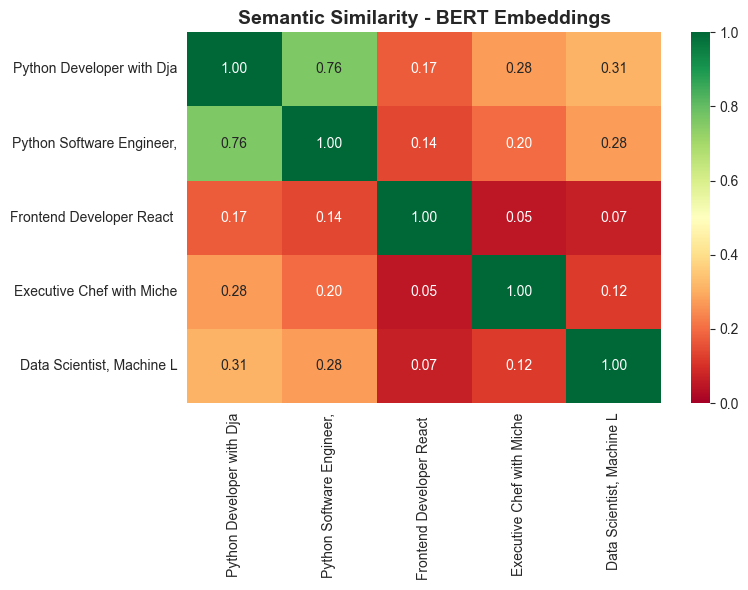

In [6]:
# Part 2: Understanding Embeddings

texts = [
    "Python Developer with Django experience",
    "Python Software Engineer, Django REST APIs",
    "Frontend Developer React and JavaScript",
    "Executive Chef with Michelin experience",
    "Data Scientist, Machine Learning, PyTorch",
]

# Generate embeddings
embeddings = model.encode(texts)

# Calculate cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    xticklabels=[t[:25] for t in texts],
    yticklabels=[t[:25] for t in texts],
    vmin=0,
    vmax=1
)

plt.title(
    'Semantic Similarity - BERT Embeddings',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [7]:
# Generating resume and JD embeddings
# We embed BOTH resume and job description separately

print("Generating resume embeddings...")

resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating job description embeddings...")

jd_embeddings = model.encode(
    df['job_description'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape: {resume_embeddings.shape}")
print(f"JD embeddings shape: {jd_embeddings.shape}")

print(f"Each text → {resume_embeddings.shape[1]}-dimensional vector")

Generating resume embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Generating job description embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Resume embeddings shape: (295, 768)
JD embeddings shape: (295, 768)
Each text → 768-dimensional vector


In [8]:
# Compute Cosine Similarity for Each Pair
# For each row: similarity between that resume and its paired JD

pair_similarities = []

for i in range(len(resume_embeddings)):
    
    sim = cosine_similarity(
        [resume_embeddings[i]],
        [jd_embeddings[i]]
    )[0][0]
    
    pair_similarities.append(sim)

# Add similarity scores to dataframe
df['bert_similarity'] = pair_similarities

print("Cosine similarity computed for all pairs.\n")

print(
    df[['match_label', 'match_score', 'bert_similarity']].head(10)
)

Cosine similarity computed for all pairs.

  match_label  match_score  bert_similarity
0      medium         0.67         0.582919
1        high         0.92         0.800309
2         low         0.25         0.437075
3         low         0.27         0.501970
4         low         0.19         0.311734
5        high         0.83         0.850748
6         low         0.20         0.410322
7         low         0.29         0.447729
8        high         0.89         0.853864
9         low         0.11         0.226123


In [9]:
# Base Model Performance:
# How Good Is BERT Out of the Box?

mae = mean_absolute_error(
    df['match_score'],
    df['bert_similarity']
)

rmse = np.sqrt(
    mean_squared_error(
        df['match_score'],
        df['bert_similarity']
    )
)

print("Base BERT Model Performance (before fine-tuning)")
print("=" * 50)

print(f"MAE  : {mae:.4f}   (lower is better)")
print(f"RMSE : {rmse:.4f}   (lower is better)")

Base BERT Model Performance (before fine-tuning)
MAE  : 0.1065   (lower is better)
RMSE : 0.1372   (lower is better)


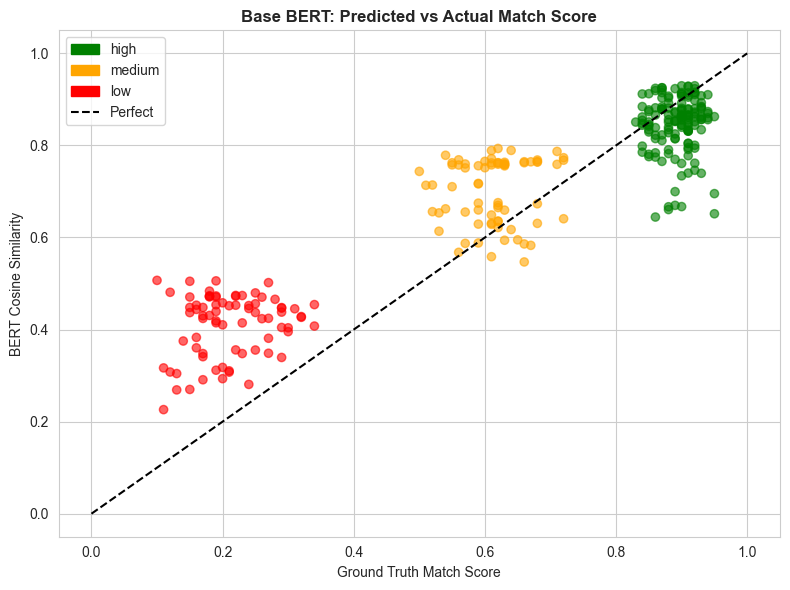

In [10]:
# Scatter: predicted vs ground truth

plt.figure(figsize=(8, 6))

# Color mapping based on labels
colors = df['match_label'].map({
    'low': 'red',
    'medium': 'orange',
    'high': 'green'
})

# Scatter plot
plt.scatter(
    df['match_score'],
    df['bert_similarity'],
    c=colors,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Perfect Prediction'
)

# Labels and title
plt.xlabel('Ground Truth Match Score')
plt.ylabel('BERT Cosine Similarity')

plt.title(
    'Base BERT: Predicted vs Actual Match Score',
    fontweight='bold'
)

# Legend
from matplotlib.patches import Patch

plt.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
    plt.Line2D(
        [0],
        [0],
        color='black',
        linestyle='--',
        label='Perfect'
    )
])

plt.tight_layout()
plt.show()

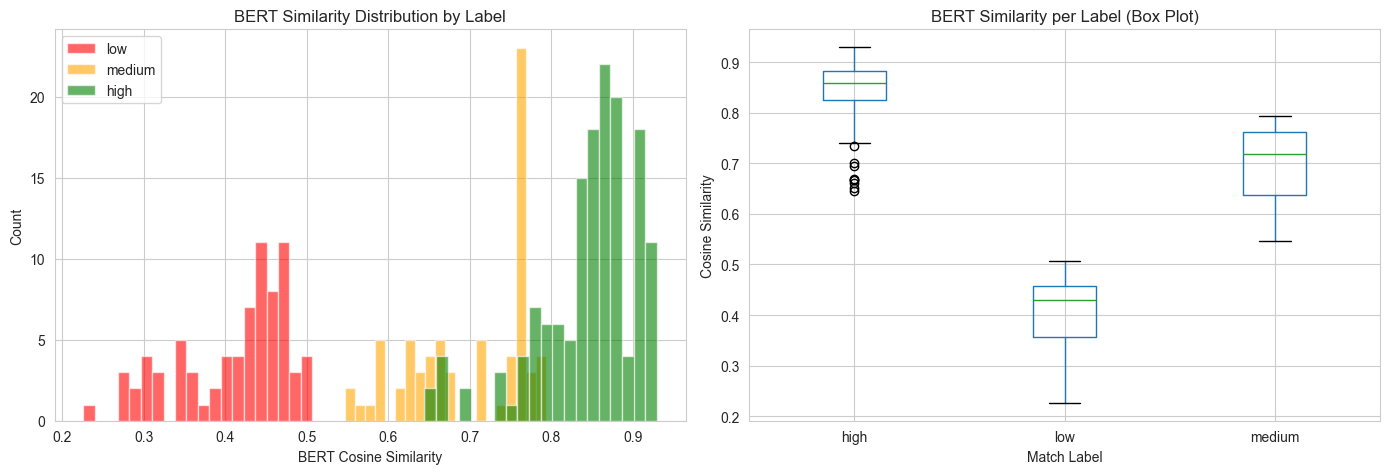


Overlap between labels = base model struggles to separate high vs low matches
Goal of fine-tuning: push these distributions apart


In [11]:
# Similarity Distribution by Label

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram:
# BERT similarity grouped by label

for label, color in [
    ('low', 'red'),
    ('medium', 'orange'),
    ('high', 'green')
]:
    
    subset = df[df['match_label'] == label]['bert_similarity']
    
    axes[0].hist(
        subset,
        bins=20,
        alpha=0.6,
        label=label,
        color=color
    )

axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')

axes[0].set_title(
    'BERT Similarity Distribution by Label'
)

axes[0].legend()


# Box plot

df.boxplot(
    column='bert_similarity',
    by='match_label',
    positions=[0, 1, 2],
    ax=axes[1]
)

axes[1].set_title(
    'BERT Similarity per Label (Box Plot)'
)

axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine Similarity')

plt.suptitle('')

plt.tight_layout()
plt.show()


# Interpretation

# If the distributions overlap heavily,
# base model can't distinguish low vs high matches well
# -> this is WHY we need to fine-tune

print(
    "\nOverlap between labels = base model struggles "
    "to separate high vs low matches"
)

print(
    "Goal of fine-tuning: push these distributions apart"
)

In [12]:
import pickle

with open('resume_embeddings.pkl', 'wb') as f:
    
    pickle.dump({
        'resume_embeddings': resume_embeddings,
        'jd_embeddings': jd_embeddings,
        'match_scores': df['match_score'].tolist(),
        'match_labels': df['match_label'].tolist(),
    }, f)

print("Saved: resume_embeddings.pkl")

print(f"resume_embeddings: {resume_embeddings.shape}")
print(f"jd_embeddings: {jd_embeddings.shape}")

print()
print("These will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
resume_embeddings: (295, 768)
jd_embeddings: (295, 768)

These will be loaded for fine-tuning.
